# Inherited Diseases Risk Predictor Using Logistics Regression

### Importing libraries

In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.model_selection import cross_val_score
import joblib

#### Loading Data

In [3]:
data = pd.read_csv('diseases.csv')
data.head()

,age,bmi,blood_pressure,cholesterol,exercise_hours_per_week,smoker,disease_risk
0,48.167958,36.991199,145.993144,230.628997,1.812575,0,1
1,39.927736,25.475634,104.427162,165.580052,1.291675,1,0
2,54.872883,29.492150,148.300873,239.535630,3.073410,1,1
3,47.380042,21.415670,103.965010,126.431713,2.239745,0,0
4,42.805707,29.353907,108.197907,190.297173,2.289710,0,0


### Exloratory Data Analysis

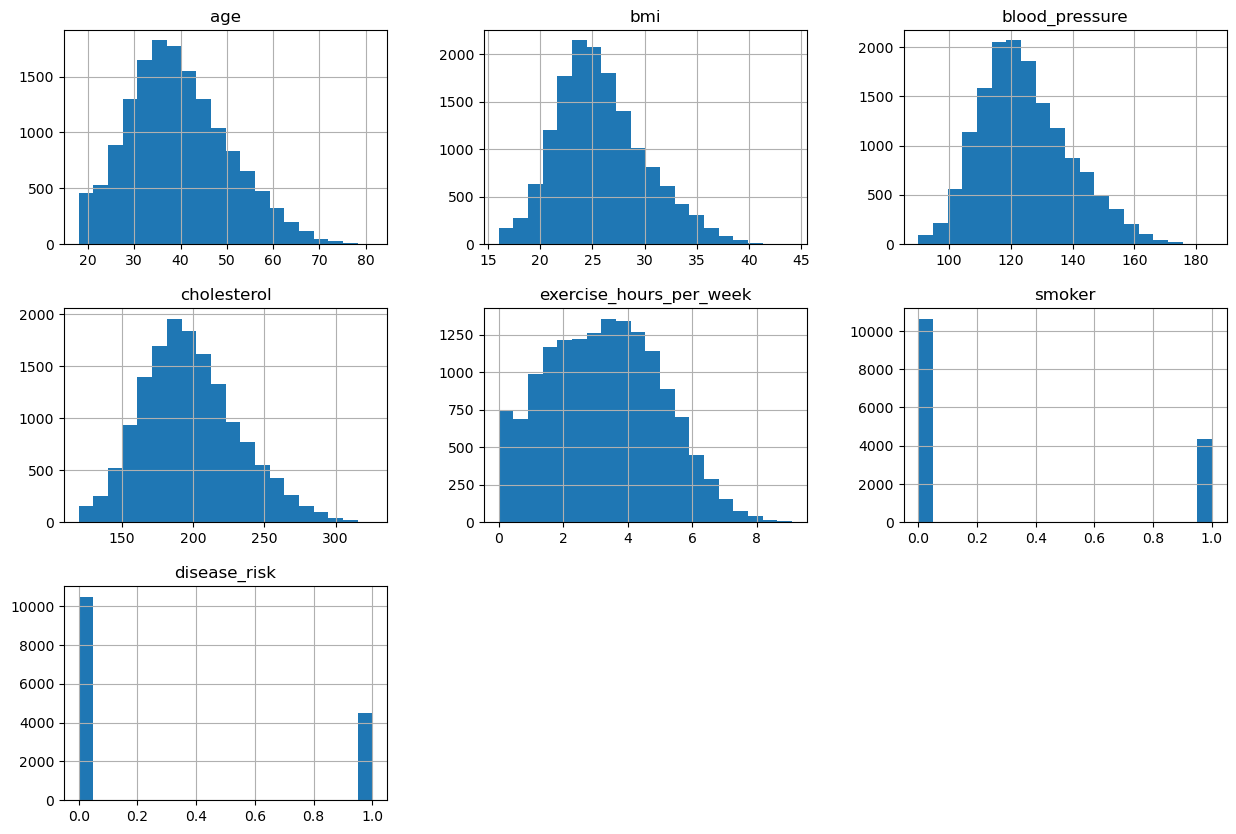

In [5]:
data.hist(figsize = (15, 10), bins = 20)
plt.show()

In [6]:
correlation = data.corr()
correlation

,age,bmi,blood_pressure,cholesterol,exercise_hours_per_week,smoker,disease_risk
age,1.000000,0.405718,0.447015,0.393684,-0.418201,0.205415,0.645648
bmi,0.405718,1.000000,0.440809,0.398115,-0.409930,0.198656,0.638613
blood_pressure,0.447015,0.440809,1.000000,0.431740,-0.437721,0.211558,0.690356
cholesterol,0.393684,0.398115,0.431740,1.000000,-0.402284,0.188370,0.609588
exercise_hours_per_week,-0.418201,-0.409930,-0.437721,-0.402284,1.000000,-0.191938,-0.641857
smoker,0.205415,0.198656,0.211558,0.188370,-0.191938,1.000000,0.308422
disease_risk,0.645648,0.638613,0.690356,0.609588,-0.641857,0.308422,1.000000


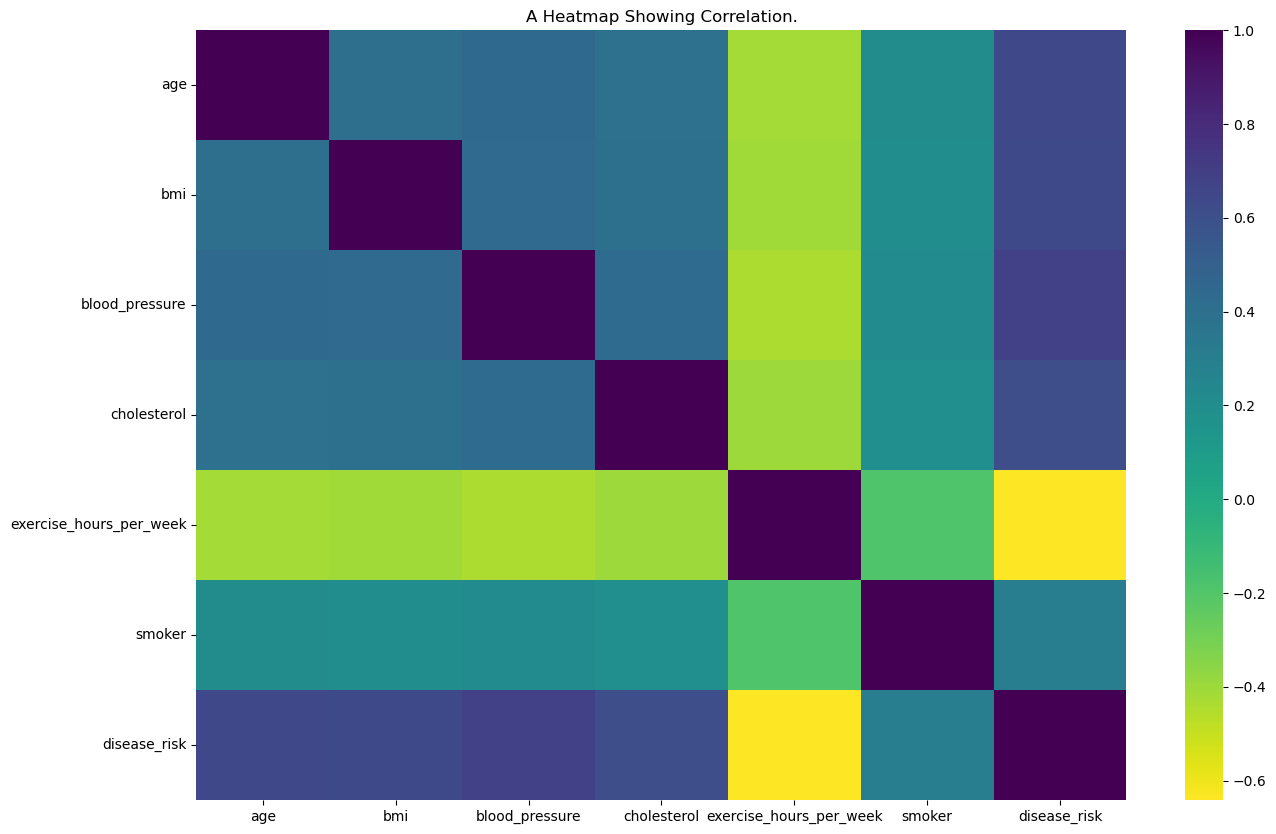

In [137]:
plt.figure(figsize = (15, 10))
sns.heatmap(correlation, cmap = 'viridis_r' )
plt.title("A Heatmap Showing Correlation.")
plt.show()

#### Class Imbalance Test

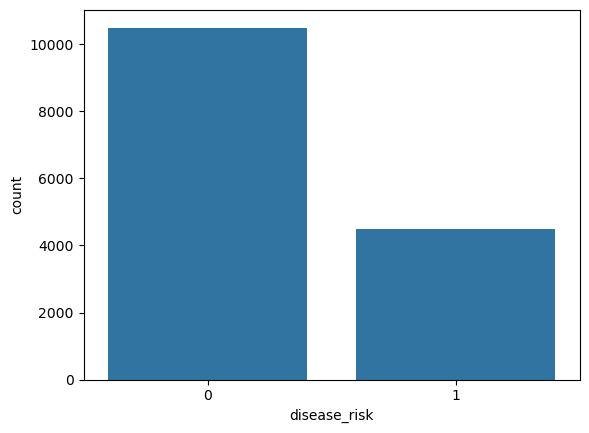

In [14]:
sns.countplot(x = 'disease_risk', data = data)
plt.show()

### Resample
**We upsample `class 1` and downsample `class 0`**

#### 1. Upsampling `class 1`

In [21]:
yes = data[data['disease_risk'] == 1]
no = data[data['disease_risk'] == 0]

In [25]:
upsampled_data = resample(
    yes,
    replace = True,
    n_samples = 7500,
    random_state = 42
)
upsampled_df = pd.concat(
    [upsampled_data, no]
)
upsampled_df.shape

(18000, 7)

#### 2. Downsampling `class 0`

In [28]:
yes = upsampled_df[upsampled_df['disease_risk'] == 1]
no = upsampled_df[upsampled_df['disease_risk'] == 0] 

In [32]:
downsampled_data = resample(
    no,
    replace = False,
    n_samples = 7500,
    random_state = 42
)

downsampled_df = pd.concat(
    [yes, downsampled_data]
)
downsampled_df.shape

(15000, 7)

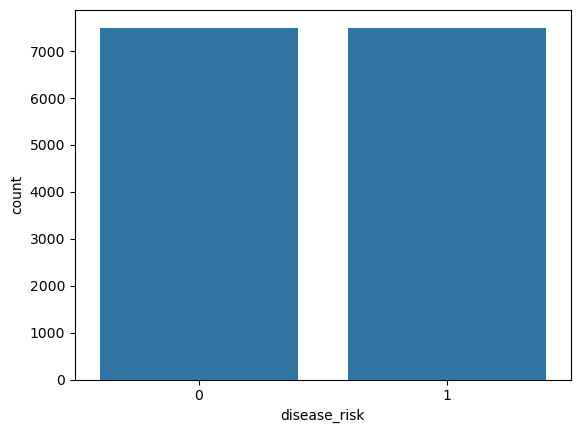

In [34]:
sns.countplot(x = 'disease_risk', data = downsampled_df)
plt.show()

**Now our dataset is balanced**

### Dataset Splitting

In [40]:
Target = data['disease_risk']
Features = data.drop('disease_risk', axis = True)

In [41]:
Features.shape

(15000, 6)

In [42]:
Target.shape

(15000,)

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    Features,
    Target,
    test_size = 0.2,
    random_state = 42
)

### Data Scaling

In [63]:
scaler = StandardScaler()
scaler.fit(X_train)
scaled_x_train = scaler.transform(X_train)
scaled_x_test = scaler.transform(X_test)

### Model Training (With Unscaled Data)

In [60]:
model1 = LogisticRegression()
model1.fit(X_train, y_train)

C:\Users\HomePC\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [70]:
y_pred1 = model1.predict(X_test)

### Unscaled Model Performance

##### 1. Accuracy Score

In [71]:
accuracy = accuracy_score(y_pred1, y_test)
print(f"Accuracy: {accuracy}")

Accuracy: 0.9843333333333333


##### 2. Confusion Matrix

In [76]:
Conf_matrix1 = confusion_matrix(y_pred1, y_test)
print(Conf_matrix1)

[[2089   25]
 [  22  864]]


##### 3. Classification Report

In [77]:
class_report = classification_report(y_pred1, y_test)
print(class_report)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2114
           1       0.97      0.98      0.97       886

    accuracy                           0.98      3000
   macro avg       0.98      0.98      0.98      3000
weighted avg       0.98      0.98      0.98      3000



##### 4. ROC Curve and AUC 

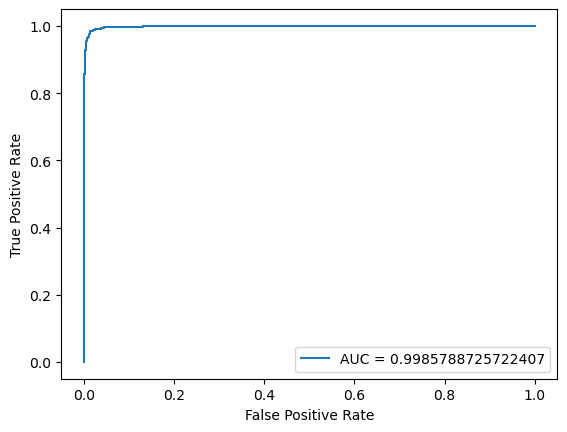

In [98]:
prob1 = model1.predict_proba(X_test)[:,1]
fpr, tpr, threshold = roc_curve(y_test, prob1) 
auc = roc_auc_score(y_test, prob1)
plt.plot(fpr, tpr, label = 'AUC = ' + str(auc))
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

##### 5. Overfitting test

In [104]:
train_pred1 = model1.predict(X_train)
print(f"Training acccuracy: {accuracy_score(y_train, train_pred1)}")

Training acccuracy: 0.9826666666666667


In [105]:
print(f"Test Acuracy: {accuracy}")

Test Acuracy: 0.9843333333333333


##### 6. Cross Validation

In [112]:
cvs = cross_val_score(model1, X_train, y_train, cv = 5)

C:\Users\HomePC\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\HomePC\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also 

In [114]:
print(f"Cross Validation: {cvs}")
print(f"Average Score: {cvs.mean()}")

Cross Validation: [0.97875    0.98541667 0.98125    0.96208333 0.98125   ]
Average Score: 0.97775


#### Generally Overfitting is likely to be absent.

### Model Training (Scaled Data)

In [65]:
model2 = LogisticRegression()
model2.fit(scaled_x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [80]:
y_pred2 = model2.predict(scaled_x_test)

### Scaled Model Performance

##### 1. Accuracy

In [82]:
accuracy2 = accuracy_score(y_pred2, y_test)
print(f"Accuracy: {accuracy2}")

Accuracy: 0.9843333333333333


##### 2. Confusion Matrix

In [83]:
Conf_matrix2 = confusion_matrix(y_pred2, y_test)
print(Conf_matrix2)

[[2089   25]
 [  22  864]]


##### 3. Classifacation Report

In [85]:
class_report2 = classification_report(y_pred2, y_test)
print(class_report2)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2114
           1       0.97      0.98      0.97       886

    accuracy                           0.98      3000
   macro avg       0.98      0.98      0.98      3000
weighted avg       0.98      0.98      0.98      3000



##### 4. ROC Curve and AUC 

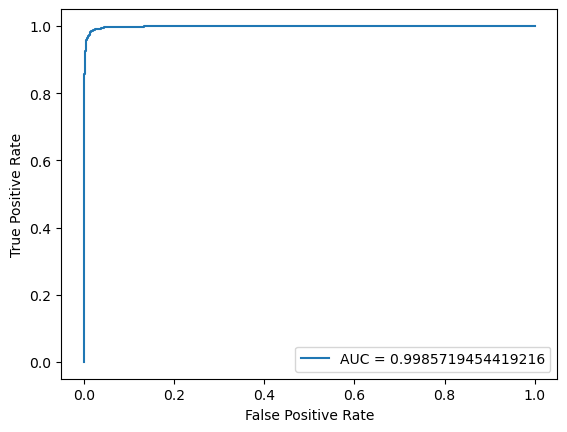

In [99]:
prob2 = model2.predict_proba(scaled_x_test)[:,1]
fpr2, tpr2, threshold2 = roc_curve(y_test, prob2) 
auc2 = roc_auc_score(y_test, prob2)
plt.plot(fpr2, tpr2, label = 'AUC = ' + str(auc2))
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

##### 5. Overfitting test

In [102]:
train_pred2 = model2.predict(scaled_x_train)
print(f"Training acccuracy: {accuracy_score(y_train, train_pred2)}")

Training acccuracy: 0.9826666666666667


In [115]:
print(f"Test Accuracy: {accuracy2}")

Test Accuracy: 0.9843333333333333


##### 5. Cross Validation

In [118]:
cvs2 = cross_val_score(model2, scaled_x_train, y_train, cv = 5)

In [120]:
print(f"Cross Validation scores: {cvs2}")
print(f"Mean Scores: {cvs2.mean()}")

Cross Validation scores: [0.98083333 0.98541667 0.9825     0.98166667 0.9825    ]
Mean Scores: 0.9825833333333334


##### Final Verdict
###### Both models are great but we will use the scaled one.

#### Saving Our Model
##### We will use joblib

In [122]:
joblib.dump(model2, 'Inherited_diseases.pkl')

['Inherited_diseases.pkl']

In [123]:
model = joblib.load('Inherited_diseases.pkl')

In [134]:
input = [[22, 20.6, 120, 170, 3, 0]]

input_scaled = scaler.transform(pd.DataFrame(input, columns = Features.columns))
output = model.predict(input_scaled)
if output == 1:
    print("Prone to inherited diseases")
else:
    print("Not prone to inherited diseases")

Not prone to inherited diseases


## THANKS !!!